In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


CURRENT_DIR = Path.cwd()


if CURRENT_DIR.name == "notebooks":
    ROOT = CURRENT_DIR.parent
else:
    ROOT = CURRENT_DIR


OUTPUT_DIR = ROOT / "outputs"


ISO_PATH = (
    OUTPUT_DIR
    / "iso_test_predictions.csv"
)


AE_PATH = (
    OUTPUT_DIR
    / "ae_test_predictions.csv"
)

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


CURRENT_DIR = Path.cwd()


if CURRENT_DIR.name == "notebooks":
    ROOT = CURRENT_DIR.parent
else:
    ROOT = CURRENT_DIR


OUTPUT_DIR = ROOT / "outputs"


ISO_PATH = (
    OUTPUT_DIR
    / "iso_test_predictions.csv"
)


AE_PATH = (
    OUTPUT_DIR
    / "ae_test_predictions.csv"
)

In [3]:
iso_results = pd.read_csv(
    ISO_PATH
)


ae_results = pd.read_csv(
    AE_PATH
)


print(
    "Isolation Forest results:",
    iso_results.shape
)


print(
    "Autoencoder results:",
    ae_results.shape
)

Isolation Forest results: (2000, 10)
Autoencoder results: (2000, 10)


In [4]:
comparison_data = iso_results[
    [
        "UDI",
        "Machine failure",
        "iso_prediction",
        "iso_anomaly_score",
    ]
].merge(
    ae_results[
        [
            "UDI",
            "Machine failure",
            "ae_prediction",
            "reconstruction_error",
        ]
    ],

    on="UDI",

    suffixes=(
        "_iso",
        "_ae"
    ),
)


comparison_data.head()

,UDI,Machine failure_iso,iso_prediction,iso_anomaly_score,Machine failure_ae,ae_prediction,reconstruction_error
0,2998,0,0,-0.054418,0,0,0.043799
1,4872,0,0,-0.098649,0,0,0.006578
2,3859,0,0,-0.097787,0,0,0.012935
3,952,0,1,0.000487,0,0,0.008376
4,6464,0,0,-0.070004,0,0,0.029767


In [5]:
labels_match = (
    comparison_data[
        "Machine failure_iso"
    ]
    ==
    comparison_data[
        "Machine failure_ae"
    ]
).all()


print(
    "Test labels aligned:",
    labels_match
)


if not labels_match:
    raise ValueError(
        "Test datasets are not aligned."
    )

Test labels aligned: True


In [6]:
def evaluate_model(
    name,
    y_true,
    y_pred,
    score,
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    tn, fp, fn, tp = cm.ravel()


    return {
        "Model": name,

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "ROC AUC": roc_auc_score(
            y_true,
            score,
        ),

        "Alerts": int(
            np.sum(y_pred)
        ),

        "True Positives": int(tp),

        "False Positives": int(fp),

        "False Negatives": int(fn),

        "True Negatives": int(tn),
    }

In [7]:
y_true = comparison_data[
    "Machine failure_iso"
].to_numpy()


iso_metrics = evaluate_model(
    name="Isolation Forest",

    y_true=y_true,

    y_pred=comparison_data[
        "iso_prediction"
    ].to_numpy(),

    score=comparison_data[
        "iso_anomaly_score"
    ].to_numpy(),
)


ae_metrics = evaluate_model(
    name="Autoencoder",

    y_true=y_true,

    y_pred=comparison_data[
        "ae_prediction"
    ].to_numpy(),

    score=comparison_data[
        "reconstruction_error"
    ].to_numpy(),
)


comparison_df = pd.DataFrame(
    [
        iso_metrics,
        ae_metrics,
    ]
)


comparison_df

,Model,Precision,Recall,F1 Score,ROC AUC,Alerts,True Positives,False Positives,False Negatives,True Negatives
0,Isolation Forest,0.128205,0.147059,0.136986,0.850696,78,10,68,58,1864
1,Autoencoder,0.107143,0.176471,0.133333,0.683253,112,12,100,56,1832


In [8]:
display_columns = [
    "Model",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Alerts",
    "False Positives",
    "False Negatives",
]


comparison_df[
    display_columns
].round(4)

,Model,Precision,Recall,F1 Score,ROC AUC,Alerts,False Positives,False Negatives
0,Isolation Forest,0.1282,0.1471,0.1370,0.8507,78,68,58
1,Autoencoder,0.1071,0.1765,0.1333,0.6833,112,100,56


In [9]:
display_columns = [
    "Model",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Alerts",
    "False Positives",
    "False Negatives",
]


comparison_df[
    display_columns
].round(4)

,Model,Precision,Recall,F1 Score,ROC AUC,Alerts,False Positives,False Negatives
0,Isolation Forest,0.1282,0.1471,0.1370,0.8507,78,68,58
1,Autoencoder,0.1071,0.1765,0.1333,0.6833,112,100,56


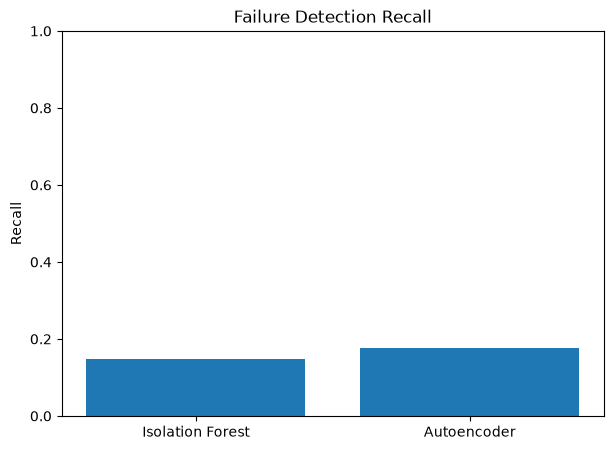

In [10]:
plt.figure(figsize=(7, 5))


plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)


plt.ylabel("Recall")
plt.title(
    "Failure Detection Recall"
)

plt.ylim(0, 1)

plt.show()

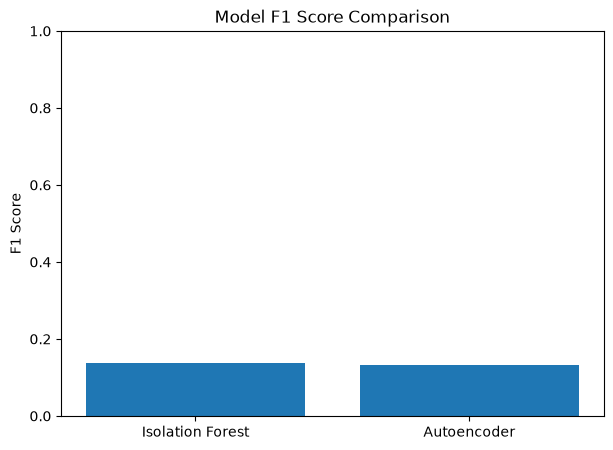

In [11]:
plt.figure(figsize=(7, 5))


plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)


plt.ylabel("F1 Score")
plt.title(
    "Model F1 Score Comparison"
)

plt.ylim(0, 1)

plt.show()

In [12]:
comparison_data[
    "model_agreement"
] = (
    comparison_data[
        "iso_prediction"
    ]
    ==
    comparison_data[
        "ae_prediction"
    ]
)


comparison_data[
    "model_agreement"
].value_counts()

model_agreement
True     1814
False     186
Name: count, dtype: int64

In [13]:
comparison_data[
    "model_agreement"
].value_counts(
    normalize=True
) * 100

model_agreement
True     90.7
False     9.3
Name: proportion, dtype: float64

In [14]:
both_anomaly = comparison_data[
    (
        comparison_data[
            "iso_prediction"
        ] == 1
    )
    &
    (
        comparison_data[
            "ae_prediction"
        ] == 1
    )
]


print(
    "Records flagged by both models:",
    len(both_anomaly)
)


print(
    "Actual failures in agreed anomalies:",
    both_anomaly[
        "Machine failure_iso"
    ].sum()
)

Records flagged by both models: 2
Actual failures in agreed anomalies: 1


In [15]:
disagreement = comparison_data[
    comparison_data[
        "model_agreement"
    ] == False
]


print(
    "Model disagreement records:",
    len(disagreement)
)


disagreement.head(20)

Model disagreement records: 186


,UDI,Machine failure_iso,iso_prediction,iso_anomaly_score,Machine failure_ae,ae_prediction,reconstruction_error,model_agreement
3,952,0,1,0.000487,0,0,0.008376,False
6,4509,0,0,-0.130009,0,1,0.164505,False
8,7886,0,0,-0.120720,0,1,0.158695,False
9,2422,0,1,0.073012,0,0,0.061294,False
14,922,0,1,0.024557,0,0,0.015320,False
21,1392,1,1,0.053092,1,0,0.067353,False
24,9602,0,1,0.000417,0,0,0.034458,False
26,885,0,1,0.008178,0,0,0.013645,False
40,4496,1,0,-0.064942,1,1,0.136253,False
43,8583,1,0,-0.015481,1,1,0.117765,False


In [16]:
best_recall_model = comparison_df.loc[
    comparison_df["Recall"].idxmax(),
    "Model"
]


best_f1_model = comparison_df.loc[
    comparison_df["F1 Score"].idxmax(),
    "Model"
]


best_auc_model = comparison_df.loc[
    comparison_df["ROC AUC"].idxmax(),
    "Model"
]


print(
    "Best Recall:",
    best_recall_model
)


print(
    "Best F1:",
    best_f1_model
)


print(
    "Best ROC AUC:",
    best_auc_model
)

Best Recall: Autoencoder
Best F1: Isolation Forest
Best ROC AUC: Isolation Forest


In [17]:
comparison_df.to_csv(
    OUTPUT_DIR
    / "model_comparison.csv",

    index=False,
)


comparison_data.to_csv(
    OUTPUT_DIR
    / "combined_test_predictions.csv",

    index=False,
)


print(
    "Comparison outputs saved successfully."
)

Comparison outputs saved successfully.


## Conclusion

The comparison shows that:

1. Autoencoder achieved higher recall and detected more actual failure records.
2. Isolation Forest generated fewer false positive alerts.
3. Isolation Forest achieved the stronger F1 score.
4. Model selection depends on whether the business prioritizes failure coverage or lower false-alert workload.
5. Records detected by both models can be treated as higher-priority investigation candidates.